Code to test the performance of shifting the data to account for misclassification errors from diffusion time in the testing environment.

In [1]:
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR.joinpath('data')
ONNX_MODEL_DIR = ROOT_DIR.joinpath('onnx_models')
INDICES_DIR = ROOT_DIR.joinpath("saved_indices")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_fwf(DATA_DIR.joinpath("ethylene_methane.txt"), skiprows=1, header=None, names=["Time", "Methane ppm", "Ethylene ppm", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"])
df.insert(1, "Target", df["Methane ppm"] > 0)
print(df)

            Time  Target  Methane ppm  Ethylene ppm       S1       S2  \
0           0.00   False          0.0           0.0   -41.98  2067.64   
1           0.01   False          0.0           0.0   -46.50  2067.88   
2           0.02   False          0.0           0.0   -36.16  2055.81   
3           0.03   False          0.0           0.0   -50.36  2053.68   
4           0.04   False          0.0           0.0   -37.30  2081.17   
...          ...     ...          ...           ...      ...      ...   
4178499  4179.00   False          0.0           0.0  2348.00  1599.20   
4178500  4179.00   False          0.0           0.0  2341.00  1605.30   
4178501  4179.00   False          0.0           0.0  2345.00  1604.00   
4178502  4179.00   False          0.0           0.0  2350.00  1594.80   
4178503  4179.00   False          0.0           0.0  2348.00  1598.80   

              S3       S4       S5       S6       S7       S8       S9  \
0         -37.13     2.28     8.63   -26.62    -8

In [3]:
print("Number of True targets:", len(df[df['Target'].isin([True])]))
print("Number of False targets:", len(df[df['Target'].isin([False])]))

Number of True targets: 1849752
Number of False targets: 2328752


In [11]:
shifts = range(15, 25, 1)
for i in shifts:
    df.insert(1, f"Target_shifted_{i}", df["Target"].shift(i*100))

ValueError: cannot insert Target_shifted_15, already exists

Setting up models to be tested

In [5]:
models = []
import xgboost as xgb
spw = len(df[df['Target'].isin([False])]) / len(df[df['Target'].isin([True])])
xgbm = xgb.XGBClassifier(
    n_estimators=3000, max_depth=3, learning_rate=0.01,
    scale_pos_weight=spw, tree_method="hist",
    subsample=0.5, colsample_bytree=0.5, min_child_weight=100,
    gamma=2.0, reg_alpha=0.5, reg_lambda=10.0,
    objective="binary:logistic", eval_metric="logloss",
    early_stopping_rounds=50, random_state=42,
    n_jobs=-1, verbosity=0,
)
models.append(xgbm)


Run the shifted data accuracy testing

In [6]:
from sklearn.metrics import accuracy_score
accuracy_scores = []
split = [.7, .15, .15]

for i in shifts:
    shifted = df[[f"Target_shifted_{i}", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
    shifted = np.delete(shifted, np.s_[0:i*100], axis=0)
    length = len(shifted)

    train_end = int(length * split[0])
    test_end = int(train_end + length * split[1])

    xtrain = shifted[:train_end, 1:]
    ytrain = shifted[:train_end, 0]
    xtest = shifted[train_end:test_end, 1:]
    ytest = shifted[train_end:test_end, 0]
    xval = shifted[test_end:length, 1:]
    yval = shifted[test_end:length, 0]

    accuracy_dict = {}

    for model in models:
        model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
        ypred = model.predict(xval)
        accuracy = accuracy_score(list(map(int,yval)), ypred)
        accuracy_dict[type(model).__name__] = accuracy
    accuracy_scores.append(accuracy_dict)
    

[0]	validation_0-logloss:0.68898	validation_1-logloss:0.69275
[1]	validation_0-logloss:0.68007	validation_1-logloss:0.68354
[2]	validation_0-logloss:0.67133	validation_1-logloss:0.67450
[3]	validation_0-logloss:0.66282	validation_1-logloss:0.66557
[4]	validation_0-logloss:0.65442	validation_1-logloss:0.65682
[5]	validation_0-logloss:0.64618	validation_1-logloss:0.64823
[6]	validation_0-logloss:0.63814	validation_1-logloss:0.63986
[7]	validation_0-logloss:0.63032	validation_1-logloss:0.63169
[8]	validation_0-logloss:0.62253	validation_1-logloss:0.62361
[9]	validation_0-logloss:0.61489	validation_1-logloss:0.61571
[10]	validation_0-logloss:0.60740	validation_1-logloss:0.60796
[11]	validation_0-logloss:0.60007	validation_1-logloss:0.60043
[12]	validation_0-logloss:0.59284	validation_1-logloss:0.59290
[13]	validation_0-logloss:0.58575	validation_1-logloss:0.58551
[14]	validation_0-logloss:0.57881	validation_1-logloss:0.57826
[15]	validation_0-logloss:0.57196	validation_1-logloss:0.57117
[1

Run this cell to include baseline accuracy

In [ ]:
base = df[["Target", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()   
length = len(base)

train_end = int(length * split[0])
test_end = int(train_end + length * split[1])

xtrain = base[:train_end, 1:]
ytrain = base[:train_end, 0]
xtest = base[train_end:test_end, 1:]
ytest = base[train_end:test_end, 0]
xval = base[test_end:length, 1:]
yval = base[test_end:length, 0]

accuracy_dict = {}

for model in models:
    model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
    ypred = model.predict(xval)
    accuracy = accuracy_score(list(map(int,yval)), ypred)
    accuracy_dict[type(model).__name__] = accuracy
accuracy_scores.insert(0, accuracy_dict)
shifts = list(shifts)
shifts.insert(0, 0)

[0]	validation_0-logloss:0.69095	validation_1-logloss:0.69464
[1]	validation_0-logloss:0.68389	validation_1-logloss:0.68693
[2]	validation_0-logloss:0.67697	validation_1-logloss:0.67938
[3]	validation_0-logloss:0.67025	validation_1-logloss:0.67210
[4]	validation_0-logloss:0.66365	validation_1-logloss:0.66476
[5]	validation_0-logloss:0.65717	validation_1-logloss:0.65764
[6]	validation_0-logloss:0.65076	validation_1-logloss:0.65063
[7]	validation_0-logloss:0.64462	validation_1-logloss:0.64393
[8]	validation_0-logloss:0.63847	validation_1-logloss:0.63717
[9]	validation_0-logloss:0.63249	validation_1-logloss:0.63057
[10]	validation_0-logloss:0.62661	validation_1-logloss:0.62419
[11]	validation_0-logloss:0.62085	validation_1-logloss:0.61790
[12]	validation_0-logloss:0.61514	validation_1-logloss:0.61164
[13]	validation_0-logloss:0.60953	validation_1-logloss:0.60549
[14]	validation_0-logloss:0.60403	validation_1-logloss:0.59945
[15]	validation_0-logloss:0.59868	validation_1-logloss:0.59351
[1

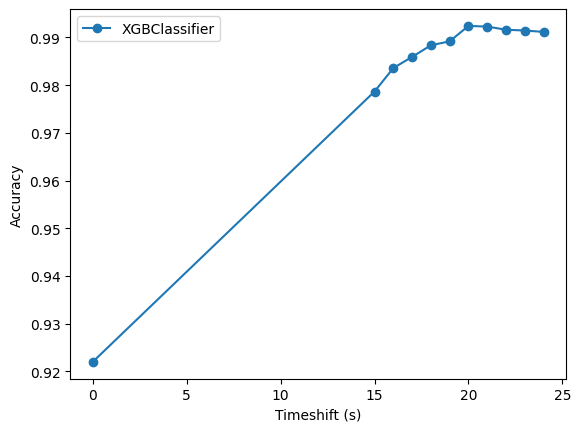

In [24]:
for model in models:
    axis = []
    for i in range(len(accuracy_scores)):
        axis.append(accuracy_scores[i][type(model).__name__])
    plt.plot(shifts, axis, label=type(model).__name__, marker="o")
plt.legend()
plt.xlabel("Timeshift (s)")
plt.ylabel("Accuracy")
plt.show()
